This project aims to develop an AI-based system for non-destructive assessment of plant health by predicting chlorophyll content from leaf images. Chlorophyll concentration is an important indicator of plant health, photosynthetic activity, and nutrient status. Traditional chlorophyll estimation methods require destructive sampling and laboratory analysis. This study explores the use of image processing and ML to provide a low-cost and sustainable alternative.

Primary SDG:
SDG 12 – Responsible Consumption and Production

Secondary SDG:
SDG 15 – Life on Land

Expected Impact:
• Early plant stress detection
• Sustainable crop monitoring
• Reduced dependence on laboratory testing
• Improved agricultural decision making

Import Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

Feature Extraction

In [2]:
# -----------------------------
# Feature functions
# -----------------------------

def extract_rgb_features(img):
    img = img.astype(np.float32)

    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    eps = 1e-6
    total = R + G + B + eps

    # Normalized channels
    r = R / total
    g = G / total
    b = B / total

    features = {}

    # Mean normalized channels
    features["r_mean"] = r.mean()
    features["g_mean"] = g.mean()
    features["b_mean"] = b.mean()

    # NEW: distribution features
    features["R_std"] = R.std()
    features["G_std"] = G.std()
    features["B_std"] = B.std()

    # Ratios
    features["G_R"] = (G / (R + eps)).mean()
    features["G_B"] = (G / (B + eps)).mean()
    features["R_B"] = (R / (B + eps)).mean()

    # Vegetation indices (RGB-only)
    features["ExG"]   = (2*G - R - B).mean()
    features["NGRDI"] = ((G - R) / (G + R + eps)).mean()
    features["VARI"]  = ((G - R) / (G + R - B + eps)).mean()

    # Brightness
    features["Intensity"] = ((R + G + B) / 3).mean()

    # Mask useful green pixels
    mask = G > np.percentile(G, 20)
    
    if np.sum(mask) > 0:
        G_masked = G[mask]
        features["G_masked_mean"] = G_masked.mean()
        features["G_masked_std"] = G_masked.std()
    else:
        features["G_masked_mean"] = 0
        features["G_masked_std"] = 0
        
    return features

def extract_texture_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    features = {}
    features["Gray_std"] = gray.std()
    features["Edge_var"] = cv2.Laplacian(gray, cv2.CV_64F).var()

    return features

def normalize_lighting(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    img[:, :, 0] = cv2.equalizeHist(img[:, :, 0])
    img = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)
    return img


# -----------------------------
# Main extraction loop
# -----------------------------
BASE_DIR = "/kaggle/input/datasets/paradiseflycatcher/plant-health/PlantHealth"

df = pd.read_csv(f"{BASE_DIR}/chlorophyll.csv")

df["Leaf ID"] = df["Leaf ID"].astype(str)

rows = []
IMG_EXTS = [".jpg", ".jpeg", ".png"]

for _, row in df.iterrows():
    leaf_id = row["Leaf ID"]
    chlorophyll = row["Chlorophyll"]

    plant = leaf_id[0]
    folder = os.path.join(BASE_DIR, plant)

    img = None
    for ext in IMG_EXTS:
        path = os.path.join(folder, leaf_id + ext)
        if os.path.exists(path):
            img = cv2.imread(path)
            if img is not None:
                break

    if img is None:
        print(f"Image not found for {leaf_id}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    color_feats = extract_rgb_features(img)
    texture_feats = extract_texture_features(img)

    row_dict = {
        "Leaf ID": leaf_id,
        "Plant": plant,
        "Chlorophyll": chlorophyll
    }

    row_dict.update(color_feats)
    row_dict.update(texture_feats)

    rows.append(row_dict)

feature_df = pd.DataFrame(rows)

feature_df.to_csv(
    "training_features_rgb_texture.csv",
    index=False
)

print("Saved training_features_rgb_texture.csv")

Saved training_features_rgb_texture.csv


In [3]:
X = feature_df.drop(columns=["Leaf ID", "Plant", "Chlorophyll"])
y = feature_df["Chlorophyll"]

In [4]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
preds = []
true_vals = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=3, random_state=42)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)[0]

    preds.append(pred)
    true_vals.append(y_test.values[0])

r2 = r2_score(true_vals, preds)
error = np.mean(np.abs(np.array(preds) - np.array(true_vals)) / np.array(true_vals)) * 100

print(f"LOOCV R2: {r2:.3f}")
print(f"LOOCV % error: {error:.2f}%")

LOOCV R2: 0.017
LOOCV % error: 53.97%


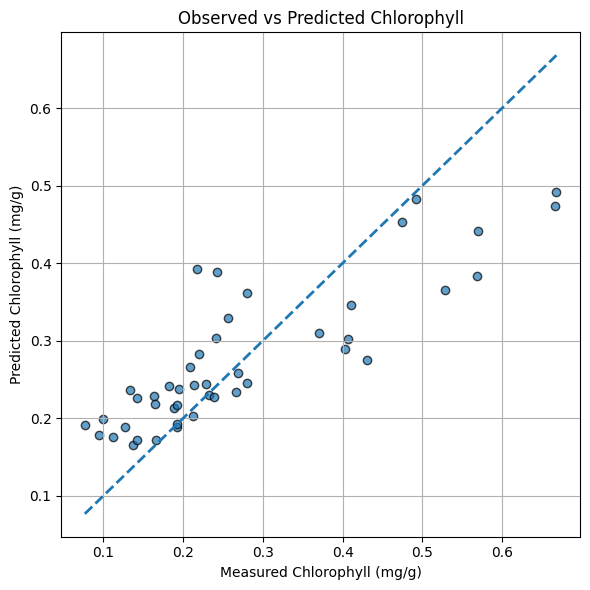

In [5]:
# Features and target
X = feature_df.drop(columns=["Leaf ID", "Plant", "Chlorophyll"])
y = feature_df["Chlorophyll"]

# Train model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    min_samples_leaf=3,
    random_state=42
)
model.fit(X, y)

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.7, edgecolor="k")
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Measured Chlorophyll (mg/g)")
plt.ylabel("Predicted Chlorophyll (mg/g)")
plt.title(f"Observed vs Predicted Chlorophyll")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "Observed vs Predicted Chlorophyll (Training set)",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [6]:
from sklearn.ensemble import RandomForestRegressor

X_train = feature_df.drop(columns=["Leaf ID", "Plant", "Chlorophyll"])
y_train = feature_df["Chlorophyll"]

final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    min_samples_leaf=3,
    random_state=42
)
final_model.fit(X_train, y_train);

In [7]:
test_meta = pd.read_csv(f"{BASE_DIR}/test_chlorophyll.csv")
test_meta["Test ID"] = test_meta["Test ID"].astype(str)

In [8]:
IMG_EXTS = [".jpg", ".jpeg", ".png"]
TEST_DIR = f"{BASE_DIR}/Test"

test_rows = []

for _, row in test_meta.iterrows():
    test_id = row["Test ID"]
    plant = row["Plant"]
    chlorophyll = row["Chlrophyll"]  # note spelling as in CSV

    img = None
    for ext in IMG_EXTS:
        img_path = os.path.join(TEST_DIR, test_id + ext)
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            if img is not None:
                break

    if img is None:
        print(f"Image not found for {test_id}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    color_feats = extract_rgb_features(img)
    texture_feats = extract_texture_features(img)

    r = {
        "Test ID": test_id,
        "Plant": plant,
        "Chlorophyll": chlorophyll
    }
    r.update(color_feats)
    r.update(texture_feats)

    test_rows.append(r)

test_df = pd.DataFrame(test_rows)

In [9]:
X_test = test_df[X_train.columns]   # SAME feature order
y_test = test_df["Chlorophyll"]

y_pred = final_model.predict(X_test)

test_df["Predicted_Chlorophyll"] = y_pred
test_df.to_csv("test_predictions_with_features.csv",index=False)

print("Saved test_predictions_with_features.csv")

Saved test_predictions_with_features.csv


In [10]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Test R2: {r2:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE: {mae:.3f}")

Test R2: 0.801
Test RMSE: 0.029
Test MAE: 0.027


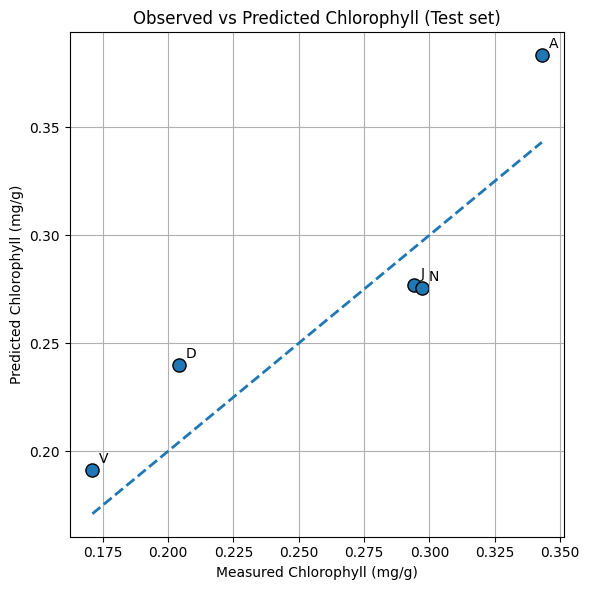

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, s=90, edgecolor="k")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--",
    linewidth=2
)

for i, txt in enumerate(test_df["Plant"]):
    plt.annotate(
        txt,
        (y_test.iloc[i], y_pred[i]),
        textcoords="offset points",
        xytext=(5,5)
    )

plt.xlabel("Measured Chlorophyll (mg/g)")
plt.ylabel("Predicted Chlorophyll (mg/g)")
plt.title("Observed vs Predicted Chlorophyll (Test set)")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "Observed vs Predicted Chlorophyll (Test set).png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [12]:
results_table = pd.DataFrame({
    "Test ID": test_df["Test ID"],
    "Plant": test_df["Plant"],
    "Measured Chlorophyll (mg/g)": np.round(y_test.values, 3),
    "Predicted Chlorophyll (mg/g)": np.round(y_pred, 3),
    "Absolute Error": np.round(abs(y_test.values - y_pred), 3)
})

display(results_table)
results_table.to_csv("Observed_vs_Predicted_Test_Data.csv", index=False)

,Test ID,Plant,Measured Chlorophyll (mg/g),Predicted Chlorophyll (mg/g),Absolute Error
0,T1,A,0.343,0.383,0.040
1,T2,D,0.204,0.240,0.036
2,T3,J,0.294,0.277,0.017
3,T4,N,0.297,0.275,0.022
4,T5,V,0.171,0.191,0.020


In [13]:
y_true = test_df["Chlorophyll"].values
y_pred = test_df["Predicted_Chlorophyll"].values

avg_abs_error = np.mean(np.abs(y_pred - y_true))
avg_true = np.mean(y_true)

percent_error = (avg_abs_error / avg_true) * 100

print(f"Average percentage error: {percent_error:.2f}%")

Average percentage error: 10.30%
